In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/2  powerplant_data.csv')
df

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
...,...,...,...,...,...
9563,15.12,48.92,1011.80,72.93,462.59
9564,33.41,77.95,1010.30,59.72,432.90
9565,15.99,43.34,1014.20,78.66,465.96
9566,17.65,59.87,1018.58,94.65,450.93


In [ ]:
## All 5 features are continuous numerical variables, where:

# AT: Ambient Temperature
# V:  Exhaust Vacuum
# AP: Ambient Pressure
# RH: Relative Humidity
# PE: Net hourly electrical energy output (Target Variable)

In [ ]:
df.shape

(9568, 5)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AT,9568.0,19.651231,7.452473,1.81,13.5100,20.345,25.72,37.11
V,9568.0,54.305804,12.707893,25.36,41.7400,52.080,66.54,81.56
AP,9568.0,1013.259078,5.938784,992.89,1009.1000,1012.940,1017.26,1033.30
RH,9568.0,73.308978,14.600269,25.56,63.3275,74.975,84.83,100.16
PE,9568.0,454.365009,17.066995,420.26,439.7500,451.550,468.43,495.76


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


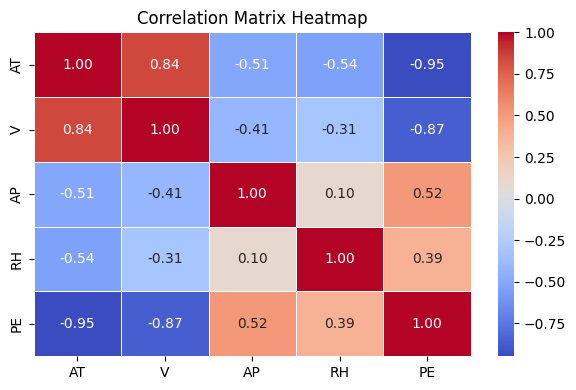

In [ ]:
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

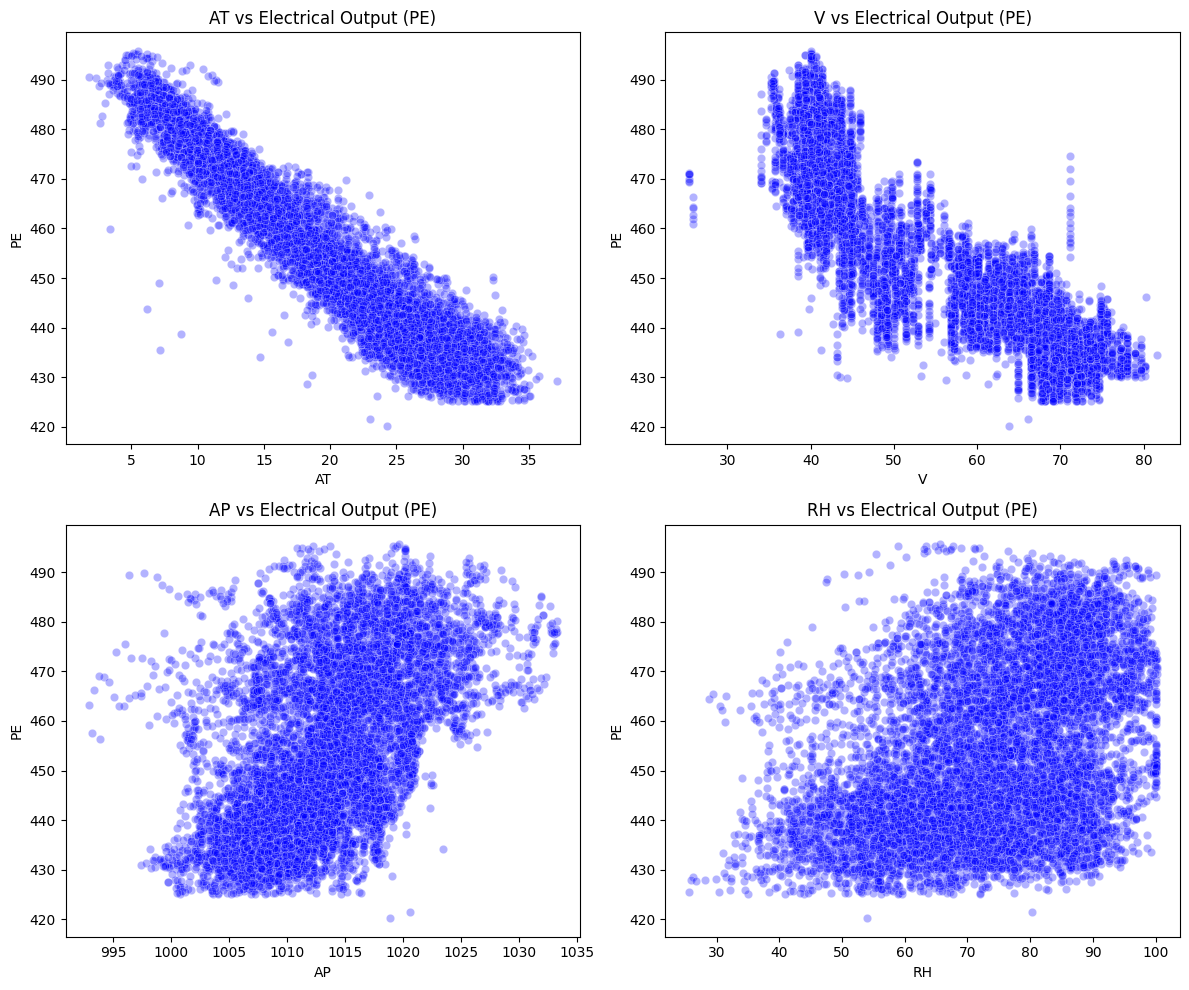

In [ ]:
features = ['AT', 'V', 'AP', 'RH']
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    # alpha=0.3 helps visualize data density and overlapping points
    sns.scatterplot(data=df, x=col, y='PE', ax=axes[i], alpha=0.3, color='blue')
    axes[i].set_title(f'{col} vs Electrical Output (PE)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('PE')

plt.tight_layout()
plt.show()

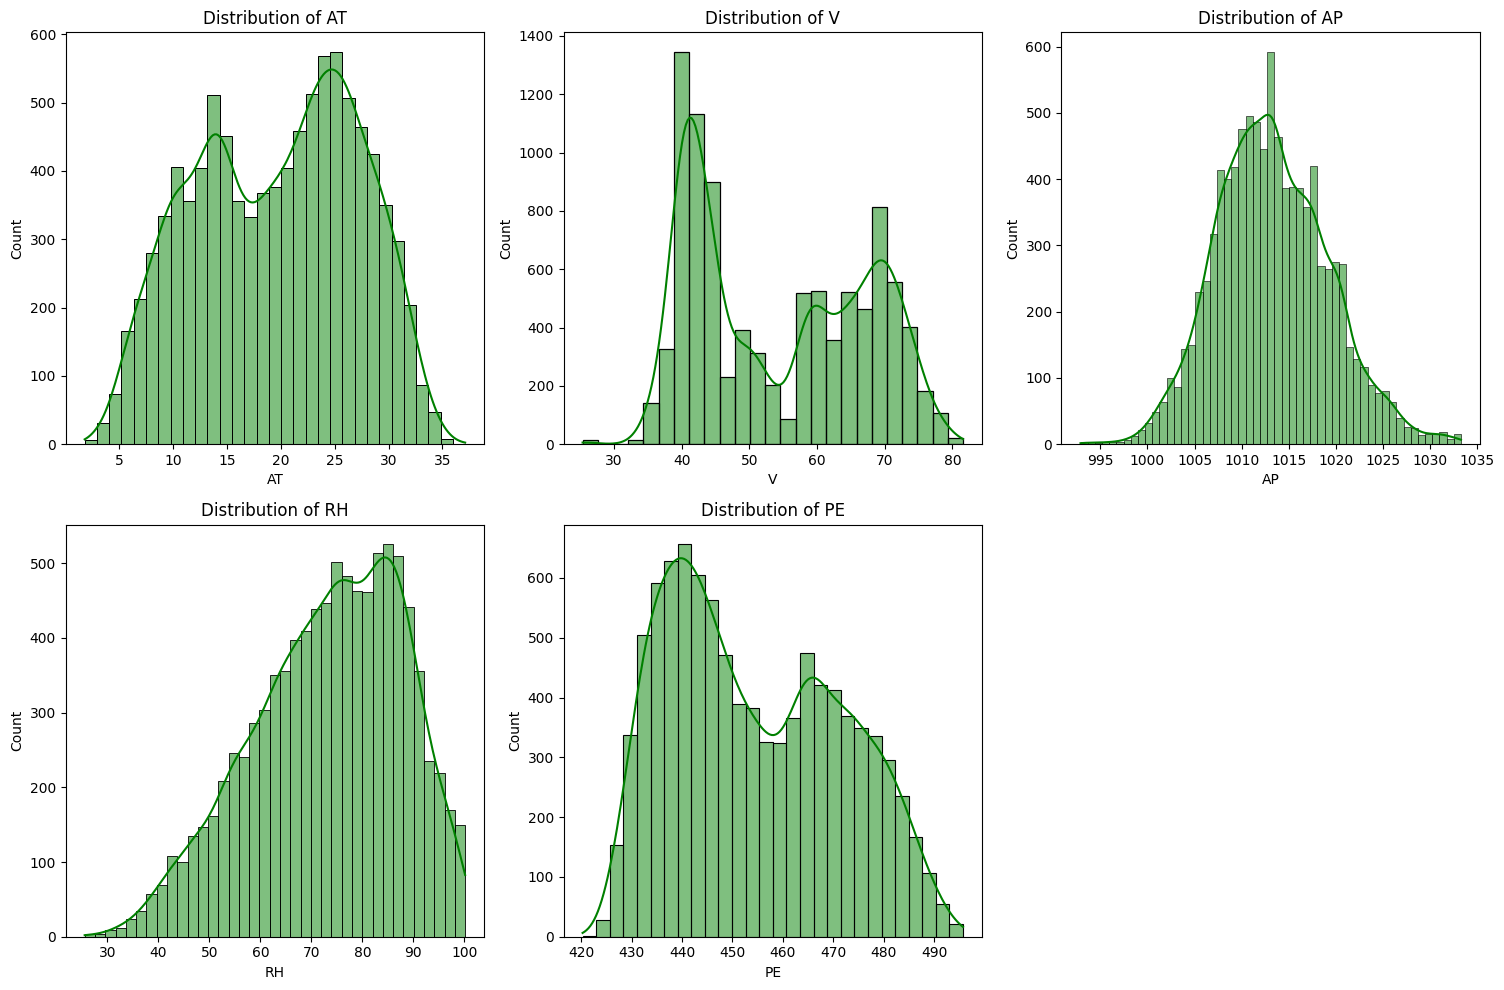

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    sns.histplot(df[col], ax=axes[i], kde=True, color='green')
    axes[i].set_title(f'Distribution of {col}')

# Remove the empty 6th subplot grid space
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

In [ ]:
# Split the features and target
x = df[["AT", "V", "AP", "RH"]]
y = df["PE"]

In [ ]:
## Train Test Split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

In [ ]:
## Model Training
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor()
model.fit(x_train, y_train)

GradientBoostingRegressor()

In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")

Mean Squared Error (MSE): 13.8892


In [ ]:
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f} MW")

Root Mean Squared Error (RMSE): 3.7268 MW


In [ ]:
## Predict Values
y_pred = model.predict(x_test)

In [ ]:
## Evaluation Matrices
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.9514608853916076

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [ ]:
## Evaluation Matrices
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.9514608853916076

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)


RandomForestRegressor(random_state=42)

In [ ]:
## Evaluation Matrices
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.9514608853916076